# 5. Loop dmr enrichment

Part of the **[Fig. 5 chapter](fig5.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{indir}L1color.tsv'`  ·  _metadata: color_
- `f'{outdir}loop_summit_subtype_dmr.txt'`  ·  _loop calls_
- `f'{outdir}loop_subtype_dmr.txt'`  ·  _loop calls_


In [ ]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [ ]:
cd /large_storage/zhoulab/zhoujt/project/ENTEx/

for i in `seq 0 35`; do
if test -e "DMR/majortype-subtype/c${i}_dmr.bed"; then 
awk '{printf("%s\t%d\t%d\n%s\t%d\t%d\n",$1,$2,$3,$4,$5,$6)}' loop/majortype/c${i}/c${i}.loop_summit.bedpe | sort -k1,1 -k2,2n -u > tmp.txt;
echo c${i} $(bedtools intersect -wa -a DMR/majortype-subtype/c${i}_dmr.bed -b tmp.txt | sort -k1,1 -k2,2n -u | wc -l) $(cat DMR/majortype-subtype/c${i}_dmr.bed | wc -l) $(cat tmp.txt | wc -l);
fi;
done | awk '{printf("%s\t%d\t%d\t%d\n",$1,$2,$3,$4)}' > analysis/loop_dmr_enrich/subtype_dmr_loop_summit.txt

for i in `seq 0 35`; do
if test -e "DMR/majortype-subtype/c${i}_dmr.bed"; then 
awk '{printf("%s\t%d\t%d\n%s\t%d\t%d\n",$1,$2,$3,$4,$5,$6)}' loop/majortype/c${i}/c${i}.loop.bedpe | sort -k1,1 -k2,2n -u > tmp.txt;
echo c${i} $(bedtools intersect -wa -a DMR/majortype-subtype/c${i}_dmr.bed -b tmp.txt | sort -k1,1 -k2,2n -u | wc -l) $(cat DMR/majortype-subtype/c${i}_dmr.bed | wc -l) $(cat tmp.txt | wc -l);
fi;
done | awk '{printf("%s\t%d\t%d\t%d\n",$1,$2,$3,$4)}' > analysis/loop_dmr_enrich/subtype_dmr_loop.txt


In [ ]:
for i in `seq 0 35`; do
if test -e "DMR/majortype-subtype/c${i}_dmr.bed"; then 
awk '{printf("%s\t%d\t%d\n%s\t%d\t%d\n",$1,$2,$3,$4,$5,$6)}' loop/majortype/c${i}/c${i}.loop_summit.bedpe | sort -k1,1 -k2,2n -u > tmp.txt;
echo c${i} $(bedtools intersect -wa -a tmp.txt -b DMR/majortype-subtype/c${i}_dmr.bed | sort -k1,1 -k2,2n -u | wc -l) $(bedtools intersect -wa -a /large_storage/zhoulab/ref/hg38/fasta/hg38.auto.anchor.bed -b DMR/majortype-subtype/c${i}_dmr.bed | sort -k1,1 -k2,2n -u | wc -l) $(cat tmp.txt | wc -l);
fi;
done | awk '{printf("%s\t%d\t%d\t%d\n",$1,$2,$3,$4)}' > analysis/loop_dmr_enrich/loop_summit_subtype_dmr.txt


In [ ]:
for i in `seq 0 35`; do
if test -e "DMR/majortype-subtype/c${i}_dmr.bed"; then 
awk '{printf("%s\t%d\t%d\n%s\t%d\t%d\n",$1,$2,$3,$4,$5,$6)}' loop/majortype/c${i}/c${i}.loop.bedpe | sort -k1,1 -k2,2n -u > tmp.txt;
echo c${i} $(bedtools intersect -wa -a tmp.txt -b DMR/majortype-subtype/c${i}_dmr.bed | sort -k1,1 -k2,2n -u | wc -l) $(bedtools intersect -wa -a /large_storage/zhoulab/ref/hg38/fasta/hg38.auto.anchor.bed -b DMR/majortype-subtype/c${i}_dmr.bed | sort -k1,1 -k2,2n -u | wc -l) $(cat tmp.txt | wc -l);
fi;
done | awk '{printf("%s\t%d\t%d\t%d\n",$1,$2,$3,$4)}' > analysis/loop_dmr_enrich/loop_subtype_dmr.txt


In [1]:
import os
import numpy as np
import pandas as pd
from glob import glob
from scipy.sparse import csr_matrix
from scipy.stats import zscore
from concurrent.futures import ProcessPoolExecutor, as_completed

import anndata
from ALLCools.mcds import MCDS, RegionDS
from ALLCools.clustering import *
from ALLCools.plot import *

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'

import warnings
warnings.filterwarnings("ignore")


In [2]:
indir = f'{ENTEX_ROOT}/'
outdir = f'{indir}analysis/loop_dmr_enrich/'


In [3]:
L1_meta = pd.read_csv(f'{indir}L1color.tsv', sep='\t', header=0, index_col=0)
# L1_meta = L1_meta.drop(['c35', 'c36'], axis=0)
L1_meta = L1_meta.drop(['c7'], axis=0)
L1_annot = L1_meta['L1_abbr'].to_dict()
L1_color = L1_meta['color'].to_dict()
L1_color.update({L1_annot[k]: L1_color[k] for k in L1_annot if k in L1_color})  # also key by name


In [4]:
import cooler
chrom_size_path = f'{REF_ROOT}/hg38/fasta/hg38.main.chrom.sizes'
chrom_sizes = cooler.read_chromsizes(chrom_size_path, all_names=True)
chrom_sizes = chrom_sizes.iloc[:22]


In [22]:
tot_bin = 249871


In [16]:
data1 = pd.read_csv(f'{outdir}loop_summit_subtype_dmr.txt', sep='\t', header=None, index_col=0, names=['L1','dmrsummit','dmrbin','summit'])
data2 = pd.read_csv(f'{outdir}loop_subtype_dmr.txt', sep='\t', header=None, index_col=0, names=['L1','dmrloop','dmrbin','loop'])
data = pd.concat([data1, data2.drop('dmrbin', axis=1)], axis=1)
data

,dmrsummit,dmrbin,summit,dmrloop,loop
L1,,,,,
c0,10190,95679,15963,33822,56841
c1,4805,63052,9755,17250,36761
c2,478,10142,2450,1699,9024
c3,6570,200197,7567,24833,29387
c4,2358,12218,26891,7217,90783
c5,921,20289,3253,3353,12870
c6,15457,147886,20729,49863,69727
c8,7632,43111,32556,22902,101295
c9,1239,9324,13206,4099,51032


In [23]:
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests as FDR

for t in ['loop','summit']:
    stats = []
    for xx,yy,zz in data[[f'dmr{t}','dmrbin',t]].values:
        _,pv,*_ = chi2_contingency([[xx,zz-xx],[yy,tot_bin-yy]])
        stats.append(pv)
    
    data[f'{t}odd'] = data[f'dmr{t}'] / data[t] / data['dmrbin'] * tot_bin
    data[f'{t}fdr'] = FDR(stats, alpha=0.05, method='fdr_bh')[1]


In [28]:
L1_meta = L1_meta.loc[L1_meta.index.isin(data.index)]

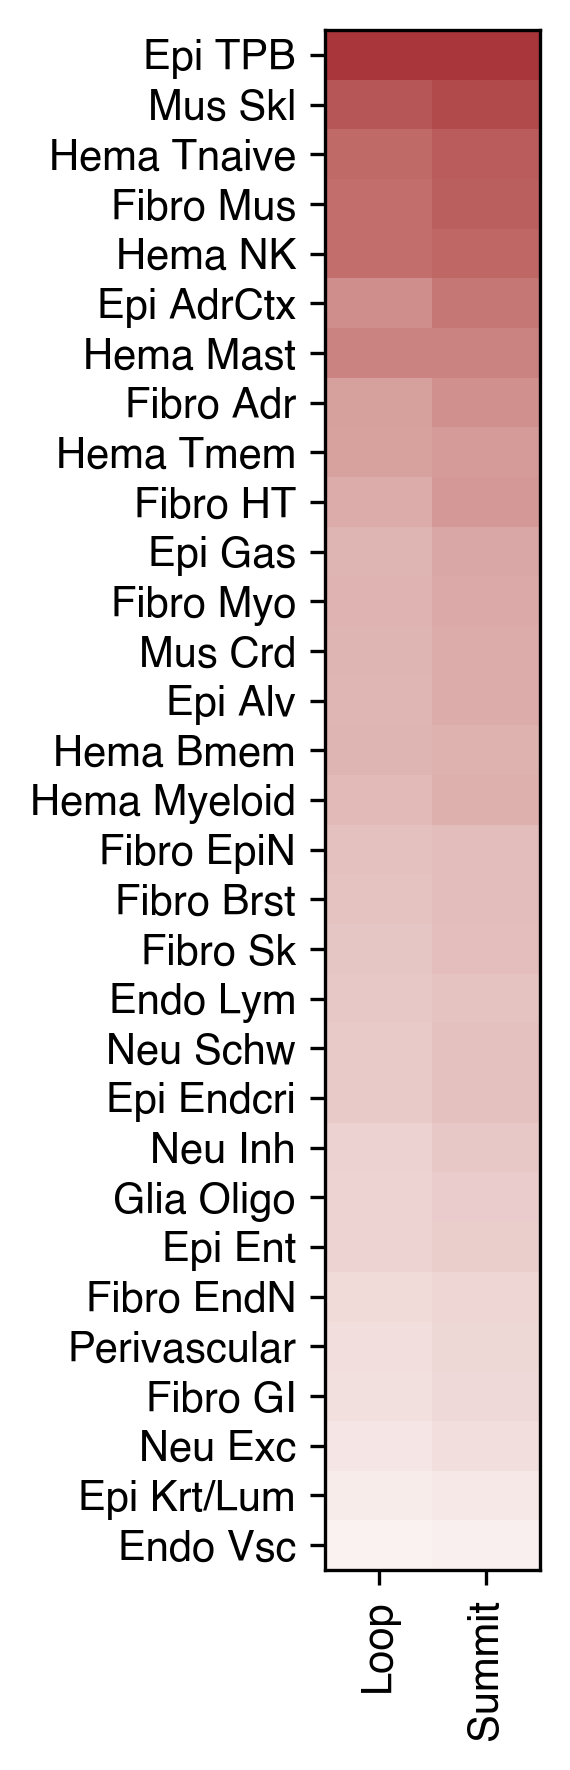

In [40]:
rorder = data[['loopodd', 'summitodd']].mean(axis=1).sort_values().index[::-1]
fig, ax = plt.subplots(figsize=(2,6), dpi=300)
ax.imshow(np.log2(data.loc[rorder, ['loopodd', 'summitodd']]), 
          cmap='vlag', vmax=2, vmin=-2, rasterized=True, aspect='auto', interpolation='none')
ax.set_yticks(np.arange(data.shape[0]))
ax.set_yticklabels(rorder.map(L1_annot))
ax.set_xticks([0,1])
ax.set_xticklabels(['Loop','Summit'], rotation=90)
fig.tight_layout()
fig.savefig(f'{outdir}loop_summit_subtypedmr_enrich.pdf', transparent=True)


In [18]:
data['dmrloop'] / data['dmrbin'] / data['loop'] * 249871

L1
c0     1.553949
c1     1.859597
c2     4.638596
c3     1.054708
c4     1.625803
c5     3.208560
c6     1.208276
c8     1.310428
c9     2.152529
c10    1.157893
c11    1.726311
c12    1.218767
c13    1.386090
c14    1.301744
c15    2.785190
c16    1.316317
c17    1.470382
c18    1.113283
c19    1.246145
c20    1.600564
c21    1.398317
c23    1.440919
c24    2.323698
c26    1.617846
c27    2.693243
c28    1.485375
c29    1.884324
c32    2.687910
c33    1.423364
c34    1.644518
c35    1.611963
dtype: float64